In [1]:
name = "openChain50_dl0_25"

In [2]:
import sqlite3
import pandas as pd
import numpy as np
np.set_printoptions(suppress=True)
import os
from IPython.display import display_markdown as md
import matplotlib.pyplot as plt

DB_FILE = name+".db"
DB_FILE_ro = "file:"+name+".db?mode=ro"

In [3]:
conn = sqlite3.connect(DB_FILE_ro)
query_metadata = """
SELECT id, startDate, completionDate, computerName, size, rs, eta, prefactors, T_bot, T_top, temperature_description, number_of_rounds, allgather_time 
FROM _experiments 
ORDER BY startDate DESC 
LIMIT 1
"""
df_exp = pd.read_sql_query(query_metadata, conn)
experimentID = int(df_exp['id'].iloc[0])#df_exp is one row so iloc[0], for last row of query df_exp use iloc[-1]
size = df_exp['size'].iloc[0]
overlapRatio = df_exp['rs'].iloc[0]
eta = df_exp['eta'].iloc[0]
prefactors = list(map(float,df_exp['prefactors'].iloc[0][1:-1:].split(',')))
T_bot = df_exp['T_bot'].iloc[0]
T_top = df_exp['T_top'].iloc[0]
temperature_description = df_exp['temperature_description'].iloc[0]
number_of_rounds = df_exp['number_of_rounds'].iloc[0]
seconds_between_rounds = df_exp['allgather_time'].iloc[0]
startDate = df_exp['startDate'].iloc[0]
completionDate = df_exp['completionDate'].iloc[0]
if temperature_description =='linear':
    temperature_description_string = ' wrong notebook!'
elif temperature_description =='geometric':
    temp_of_bin = lambda i : round(T_bot*pow((T_top/T_bot), i/(size-1)), 6)
    temperature_description_string = ' temperature intervals are discretised geometrically into '+str(size)+' bins'
else:
    temperature_description_string = ' temperature intervals discretised into '+str(number_of_rounds//2)+' bins, all parallel systems anneal at the same fixed temperature, temperature intervals traversed from low to high then back to low'

#initial Config data ---> taken from first frame of rank 0
cur = conn.cursor()
cur.execute("""SELECT * FROM _experiments_all_curves WHERE experimentID = ? AND frameNumber = 1 AND rankNumber = 0 """, (experimentID,))
row = cur.fetchone()
edgeLength = row[8]
curveLength =  row[7]
sphereCount = row[9]
reachConstraint = row[10]
cur.execute("""SELECT inputSphereRadius FROM _measures WHERE curveID = ?""", (row[0], ))
inputSphereRadius = cur.fetchone()[0]

conn.close()

MARKDOWN='''## Experimenting with '''+name+''' experiment id $='''+str(experimentID)+'''$

- $r_{s} = '''+str(overlapRatio)+'''$, and  $\\eta ='''+str(eta)+'''$ with input sphere $R(1 + r_{s}^{*}) = '''+str(inputSphereRadius)+'''$, and embedded tube radius $'''+str(reachConstraint)+'''$ the curve is interpolated with '''+str(sphereCount)+''' balls with (fixed) approximate edge length $dl='''+str(edgeLength)+'''$.

- Coefficients are $\\alpha_{0} = '''+str(prefactors[0])+'''$, $\\alpha_{1} = '''+str(prefactors[1])+'''$, $\\alpha_{2} = '''+str(prefactors[2])+'''$, $\\alpha_{3} = '''+str(prefactors[3])+'''$

- Computing over '''+str(size)+''' systems  with temperature $T\in['''+str(T_bot)+''','''+str(T_top)+''']$, '''+temperature_description_string+'''.

- Each round lasting '''+str(seconds_between_rounds)+''' seconds for '''+str(number_of_rounds)+''' rounds.

- Experiment computed for '''+str(round((number_of_rounds*seconds_between_rounds)/(60*60*24), 3))+''' days.'''
md(MARKDOWN, raw=True)

## Experimenting with openChain50_dl0_25 experiment id $=1$

- $r_{s} = 0.1$, and  $\eta =0.05$ with input sphere $R(1 + r_{s}^{*}) = 1.10856$, and embedded tube radius $201$ the curve is interpolated with 0.25001 balls with (fixed) approximate edge length $dl=50.001$.

- Coefficients are $\alpha_{0} = 59.95606$, $\alpha_{1} = -0.45881$, $\alpha_{2} = 0.00595$, $\alpha_{3} = 0.0007$

- Computing over 6 systems  with temperature $T\in[0.0005,5.0]$,  temperature intervals discretised into 20 bins, all parallel systems anneal at the same fixed temperature, temperature intervals traversed from low to high then back to low.

- Each round lasting 10000.0 seconds for 40 rounds.

- Experiment computed for 4.63 days.

In [4]:
#normalised_energy = float(line[18]) # (E - E_0)/L
def compute_normalised_energy(V, A, C, X, V_0, A_0, C_0, X_0, L):
    return (prefactors[0]*(V - V_0) + prefactors[1]*(A - A_0) + prefactors[2]*(C - C_0) + prefactors[3]*(X - X_0))/L
        

In [5]:
with sqlite3.connect(DB_FILE_ro) as conn: #closing automatically handled with "with ..."
    query_curves = f"""
    SELECT id, frameNumber, rankNumber, time_in_sequence, temperature, energy, L
    FROM _experiments_all_curves 
    WHERE experimentID = {experimentID}
    ORDER BY rankNumber, frameNumber
    """
    df_curves = pd.read_sql_query(query_curves, conn)
    curve_ids_str = ",".join(map(str, df_curves['id'].unique()))
    
    query_measures = f"""
    SELECT * FROM _measures 
    WHERE curveID IN ({curve_ids_str})
    """
    df_measures = pd.read_sql_query(query_measures, conn)
    

In [6]:
df_curves.head()

,id,frameNumber,rankNumber,time_in_sequence,temperature,energy,L
0,1,1,0,0.000286,0.0005,0.000000,50.001
1,2,1,0,51.069722,0.0005,-0.000179,50.001
2,3,2,0,165.430666,0.0005,-0.000318,50.001
3,4,3,0,286.144075,0.0005,-0.000587,50.001
4,5,4,0,344.348598,0.0005,-0.000638,50.001


In [7]:
print(df_curves['temperature'].unique())

[0.0005   0.000812 0.001318 0.002141 0.003476 0.005644 0.009165 0.014882
 0.024165 0.039238 0.063714 0.103457 0.167991 0.27278  0.442933 0.719225
 1.167861 1.896345 5.       3.079241]


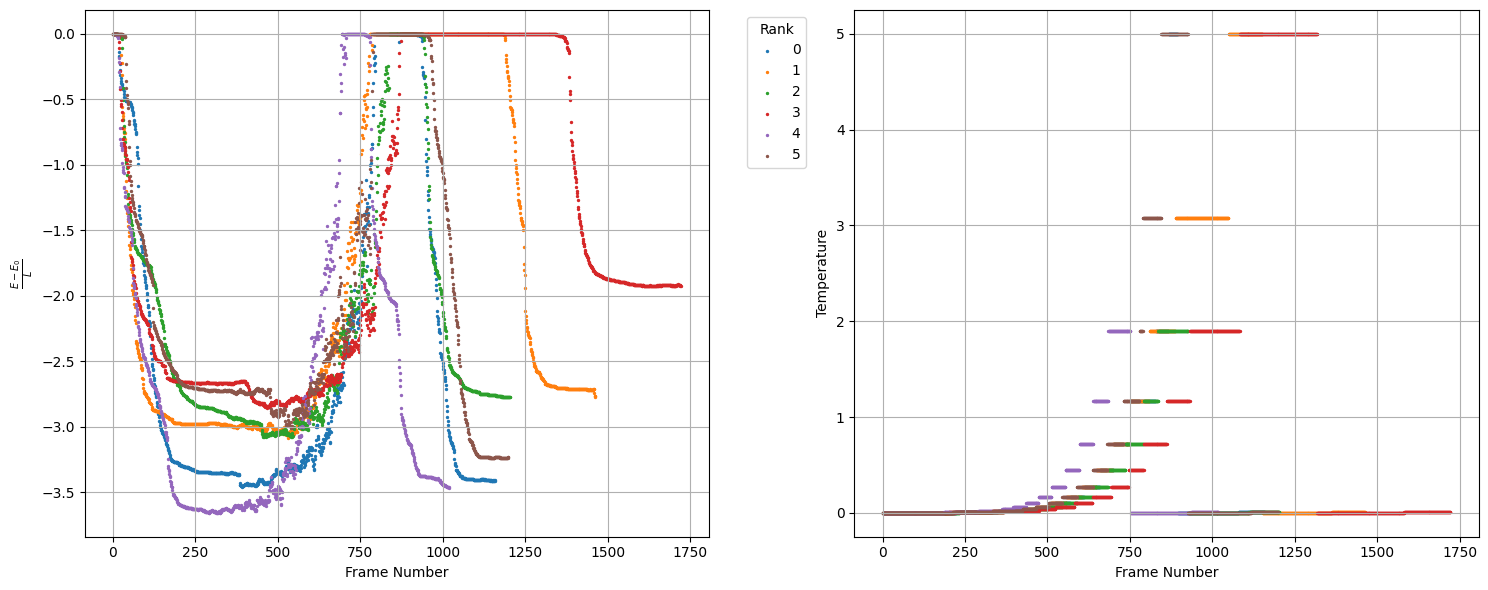

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6), sharex=True)

for rank, group in df_curves.groupby('rankNumber'):
    ax1.scatter(group['frameNumber'], group['energy'], s=2, label=f"{rank}")
    ax2.scatter(group['frameNumber'], group['temperature'], s=2, label=f"{rank}")

ax1.set_ylabel(r"$\frac{E - E_{0}}{L}$")
ax1.set_xlabel("Frame Number")
ax1.grid()
ax1.legend(title="Rank", bbox_to_anchor=(1.05, 1), loc='upper left')

ax2.set_xlabel("Frame Number")
ax2.set_ylabel("Temperature")
ax2.grid()

plt.tight_layout()

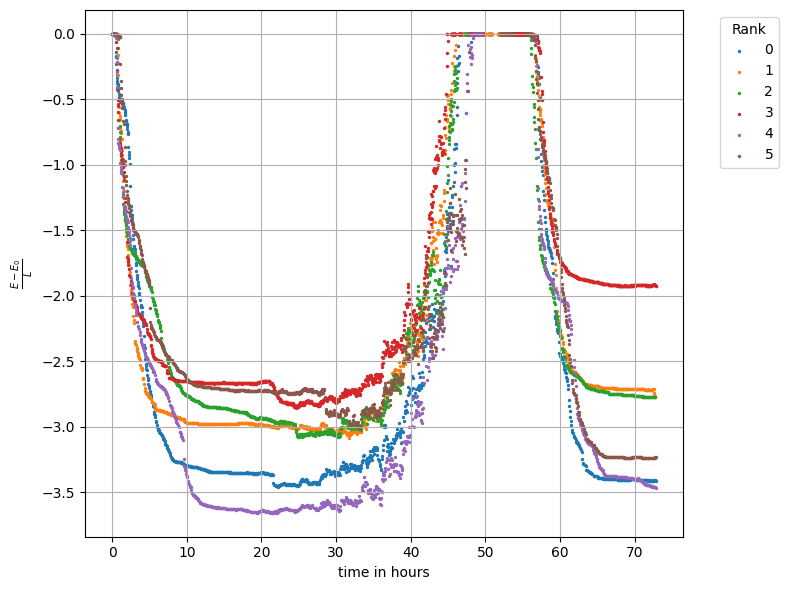

In [9]:
plt.figure(figsize=(8, 6))
for rank, group in df_curves.groupby('rankNumber'):
    plt.scatter((np.array(group['time_in_sequence'])/(60*60)).tolist(), group['energy'], s=2, label=f"{rank}")

plt.xlabel("time in hours")
plt.ylabel(r"$\frac{E - E_{0}}{L}$")
plt.legend(title="Rank", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid()
plt.tight_layout()

In [10]:
orga_info = []

for rank, group in df_curves.groupby('rankNumber'):
    # Find the row where energy is at its minimum
    min_energy_idx = group['energy'].idxmin()
    min_row = group.loc[min_energy_idx]
    
    # Calculate ranges for this specific rank
    e_range = group['energy'].max() - group['energy'].min()
    t_range = group['temperature'].max() - group['temperature'].min()
    
    # Print out matching your exact style
    print(f"Rank = {rank}  MIN E = {min_row['energy']:.10f} curve id = {group['energy'].idxmin()}, frnber= {int(min_row['frameNumber'])} T= {min_row['temperature']:.6f} temps in ["+str(group['temperature'].min())+","+str(group['temperature'].max())+"] and energy in ["+str(group['energy'].min())+","+str(group['energy'].max())+"]")
    
    # Append to your tracking list
    orga_info.append({
        "rank": rank,
        "curveID": min_row['id'],  # Pulls the exact curve ID for the minimum row
        "min_energy": min_row['energy'],
        "frame_number": int(min_row['frameNumber']),
        "temp_at_min": min_row['temperature']
    })

Rank = 0  MIN E = -3.4554843000 curve id = 392, frnber= 392 T= 0.014882 temps in [0.0005,5.0] and energy in [-3.4554843,0.00032396]
Rank = 1  MIN E = -3.0833827400 curve id = 1692, frnber= 532 T= 0.103457 temps in [0.0005,5.0] and energy in [-3.08338274,5.223e-05]
Rank = 2  MIN E = -3.0768965400 curve id = 3080, frnber= 456 T= 0.024165 temps in [0.0005,1.896345] and energy in [-3.07689654,7.97e-06]
Rank = 3  MIN E = -2.8529161500 curve id = 4295, frnber= 466 T= 0.024165 temps in [0.0005,5.0] and energy in [-2.85291615,2.734e-05]
Rank = 4  MIN E = -3.6551778300 curve id = 5877, frnber= 325 T= 0.014882 temps in [0.0005,1.896345] and energy in [-3.65517783,2.741e-05]
Rank = 5  MIN E = -3.2387122800 curve id = 7761, frnber= 1189 T= 0.005644 temps in [0.0005,5.0] and energy in [-3.23871228,3.751e-05]


In [11]:

#add information of lowest energy etc. to the _experiments table
min_record = min(orga_info, key=lambda x: x['min_energy'])

min_energy_val = min_record['min_energy'] #energy is normalised E-E_0/L
best_curve_id = min_record['curveID']
min_energy_computed = " (E - E0)/L at "+str(min_record['curveID'])

print("minimum energy in experiment", min_energy_val, "for curve on rank", df_curves[df_curves['id'] == best_curve_id]['rankNumber'].values[0], "at frame", df_curves[df_curves['id'] == best_curve_id]['frameNumber'].values[0]) 

with sqlite3.connect(DB_FILE) as conn:
    # This isolation level forces SQLite to clear any pending reading states
    conn.isolation_level = None  
    cursor = conn.cursor()
    
    # Run a quick check right inside this clean session
    cursor.execute("SELECT id FROM _experiments WHERE id = ?", [experimentID])
    exists = cursor.fetchone()
    print(f"\nClean session check -> Does ID {experimentID} exist?: {'Yes' if exists else 'No'}")
    
    if exists:
        query_update = """
        UPDATE _experiments 
        SET min_energy_normalised = ?, min_energy_curve_id = ?
        WHERE id = ?
        """
        cursor.execute(query_update, [min_energy_val, best_curve_id, experimentID])
        
        # Manually commit since we turned off auto-isolation
        conn.commit()
        print(f"Rows successfully updated: {cursor.rowcount}")
    else:
        print("Skipping update because the ID still wasn't found in this session.")

minimum energy in experiment -3.65517783 for curve on rank 4 at frame 325

Clean session check -> Does ID 1 exist?: Yes
Rows successfully updated: 1


In [12]:
import gc

print("Cleaning up database connections...")

# 1. Look through all active variables in the notebook's memory
for var_name in list(globals().keys()):
    var = globals()[var_name]
    
    # If the variable is an active SQLite connection, shut it down
    if isinstance(var, sqlite3.Connection):
        try:
            var.close()
            print(f"  -> Closed lingering connection variable: '{var_name}'")
        except sqlite3.ProgrammingError:
            # Connection was already closed
            pass

# 2. Force Python to clear cached memory objects holding file handles
gc.collect()

print("\nDatabase is completely unlocked and ready for external use!")

Cleaning up database connections...
  -> Closed lingering connection variable: 'conn'

Database is completely unlocked and ready for external use!
